# 🎓 Variational Autoencoders (VAEs) — A University Introduction
### From First Principles to Hands-On Image Generation

---

> **Audience:** Undergraduate and postgraduate students in Computer Science, Data Science, Mathematics, or any STEM discipline curious about modern generative AI.
>
> **Prerequisites:** Basic Python, some familiarity with linear algebra and probability.

### What You Will Learn
1. What VAEs are — intuitively and mathematically
2. How Artificial Neural Networks (ANNs) form the building blocks
3. Pros and cons of VAEs versus alternatives
4. Best use cases in academia and industry
5. **Hands-on:** Train a VAE on the MNIST handwritten digit dataset and *generate new digits*

---

## 1. Intuition — What Problem Does a VAE Solve?

### The Compression Analogy
Imagine you have 10,000 high-resolution photographs of handwritten digits. Each image is 28×28 = **784 pixels**. Storing and processing 784 numbers per image is expensive. But do all 784 pixels carry independent information? No — an image of the digit '3' has a specific curved structure. Its *essence* can be captured in far fewer numbers.

An **Autoencoder** learns this compression automatically:

```
  [784 pixels]  →  ENCODER  →  [small latent vector, e.g. 2 numbers]  →  DECODER  →  [784 pixels reconstructed]
```

### The 'Variational' Upgrade
A plain autoencoder maps each image to a *single point* in the latent space. Points between known images are meaningless — you cannot smoothly interpolate or generate new images.

A **Variational Autoencoder (VAE)** maps each image to a **probability distribution** (a Gaussian bell curve centred at μ with spread σ). This forces the latent space to be:
- **Continuous** — nearby points decode to similar-looking images
- **Complete** — you can sample any point and get a plausible image

```
IMAGE  →  ENCODER ANN  →  μ, σ  →  sample z ~ N(μ, σ²)  →  DECODER ANN  →  RECONSTRUCTED IMAGE
                                                        ↑
                              At generation time: sample z directly from N(0,1)
```

---

## 2. The Mathematics (Accessible Version)

### The VAE Objective
We want to maximise the probability that the model can explain our data. This leads to maximising the **Evidence Lower BOund (ELBO)**:

$$\mathcal{L} = \underbrace{\mathbb{E}_{q(z|x)}[\log p(x|z)]}_{\text{Reconstruction Term}} - \underbrace{D_{KL}\left(q(z|x) \| p(z)\right)}_{\text{KL Divergence Term}}$$

| Term | Plain English |
|---|---|
| **Reconstruction Term** | How well can the decoder reproduce the input from the compressed code? |
| **KL Divergence Term** | How close is the learned distribution to a standard Normal N(0,I)? (regularisation) |

In practice, we **minimise the negative ELBO** (equivalently, minimise the loss below).

### The Reparameterisation Trick
We cannot back-propagate through a random sampling step `z ~ N(μ, σ²)`. Instead:

$$z = \mu + \sigma \odot \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, I)$$

The randomness is *separated* into ε — gradients flow cleanly through μ and σ.

---

## 3. Artificial Neural Networks as VAE Building Blocks

Both the Encoder and Decoder are **Artificial Neural Networks**: layers of neurons where each neuron computes:

$$y = f\left(\sum_{i} w_i x_i + b\right)$$

where $w_i$ = learned weights, $b$ = bias, $f$ = activation function.

```
ENCODER ANN                                  DECODER ANN
──────────────────────────────               ──────────────────────────────
Input: x ∈ ℝ⁷⁸⁴  (28×28 image)             Input: z ∈ ℝᵈ  (latent vector)
  ↓  Dense(784 → 256)  + ReLU                 ↓  Dense(d → 256)  + ReLU
  ↓  Dense(256 → 128)  + ReLU                 ↓  Dense(256 → 512)  + ReLU
  ↓  Dense(128 → 64)   + ReLU                 ↓  Dense(512 → 784) + Sigmoid
  ↓                                        Output: x̂ ∈ [0,1]⁷⁸⁴  (pixel probs)
  ├── Dense(64 → d):  μ  (mean)
  └── Dense(64 → d):  log σ²
```

**Key ANN choices for VAEs:**
- **ReLU** activation in hidden layers — fast, avoids vanishing gradients
- **Sigmoid** on decoder output — outputs pixel probabilities in [0,1]
- **No activation** on μ and log σ² — these can be any real number
- **Adam optimiser** — adaptive learning rates, works well in practice

---

## 4. Pros & Cons of VAEs

### ✅ Advantages

| Advantage | Why It Matters |
|---|---|
| **Principled probabilistic framework** | Built on variational inference — mathematically well-grounded |
| **Smooth, continuous latent space** | Interpolation between data points gives meaningful results |
| **Generative** | Can synthesise entirely new samples by sampling the latent space |
| **Unsupervised / self-supervised** | No labels needed — learns structure from data alone |
| **Disentanglement** | With β-VAE, different latent dimensions can correspond to interpretable factors |
| **Dimensionality reduction** | Excellent for visualising high-dimensional data in 2D/3D |
| **Anomaly detection** | High reconstruction error = anomaly |

### ❌ Disadvantages

| Disadvantage | Detail |
|---|---|
| **Blurry image generation** | MSE/BCE loss encourages averaging → soft, blurry outputs (GANs are sharper) |
| **Posterior collapse** | KL term may force decoder to ignore latent code for powerful decoders |
| **Approximate inference** | ELBO is a lower bound — we never compute the true posterior |
| **Sensitive to hyperparameters** | Latent dimension, β, architecture matter and require tuning |
| **Not the best at sample quality** | Diffusion models and GANs produce sharper, more realistic images |

### VAE vs Alternatives

| Method | Latent Space | Sample Quality | Training Stability | Interpretability |
|---|---|---|---|---|
| **VAE** | Structured, smooth | Moderate | Stable | Good |
| **GAN** | Less structured | High | Often unstable | Poor |
| **Diffusion Model** | N/A (iterative) | Very High | Stable | Moderate |
| **Plain Autoencoder** | Unstructured | Moderate | Stable | Poor |

---

## 5. Best Use Cases

VAEs shine when you need a **structured, continuous latent space** rather than just the highest possible image quality.

### Top Use Cases

1. **Drug discovery** — Encode molecular structures into a continuous latent space, then optimise in that space to design novel molecules with desired properties (e.g., high binding affinity, low toxicity).

2. **Anomaly detection** — Train on normal data; high reconstruction error = anomaly. Used in manufacturing quality control, medical imaging, and network intrusion detection.

3. **Data augmentation** — Generate synthetic training samples for rare classes (e.g., rare disease images).

4. **Representation learning / dimensionality reduction** — Visualise high-dimensional datasets (scRNA-seq, text embeddings) in 2D/3D.

5. **Recommender systems** — Collaborative filtering VAEs (VAE-CF) outperform matrix factorisation on sparse user-item data.

6. **Missing data imputation** — Decode from partially observed inputs using the structured latent space.

7. **Speech / music synthesis** — Learn a compact latent representation of audio features.

---

## 6. Hands-On: Train a VAE on MNIST and Generate New Digits

We will:
1. Load the MNIST dataset (70,000 handwritten digit images)
2. Build a VAE with a **2D latent space** (so we can visualise it)
3. Train it
4. Reconstruct test images
5. **Generate brand-new digits** by sampling the latent space
6. Explore the latent space — what does each dimension mean?

In [1]:
# Install dependencies
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch', 'torchvision',
                       'numpy', 'matplotlib', '--quiet'])
print('All dependencies installed.')

All dependencies installed.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

torch.manual_seed(0)
np.random.seed(0)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


Training samples : 60000
Test samples     : 10000
Image shape      : torch.Size([1, 28, 28])  (C × H × W)


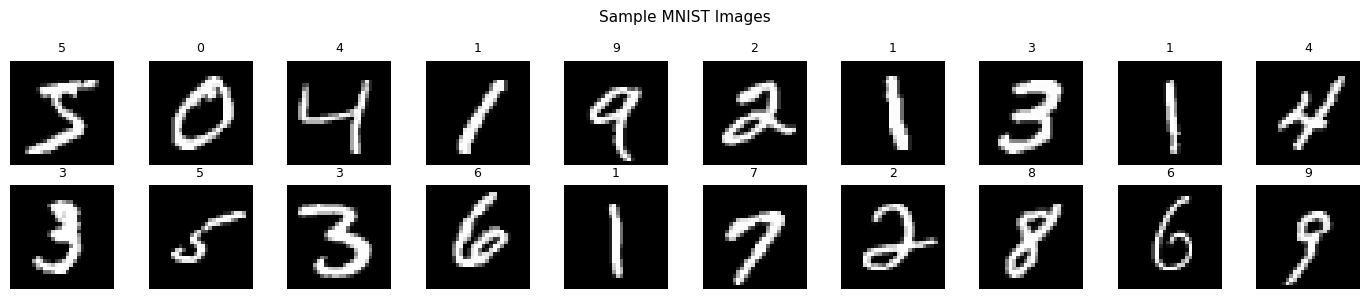

In [3]:
# Load MNIST — 60,000 training + 10,000 test images of handwritten digits 0-9
transform = transforms.ToTensor()  # Converts images to [0,1] float tensors

train_set = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_set  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=128, shuffle=False)

print(f'Training samples : {len(train_set)}')
print(f'Test samples     : {len(test_set)}')
print(f'Image shape      : {train_set[0][0].shape}  (C × H × W)')

# Visualise a few examples
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i in range(20):
    img, label = train_set[i]
    axes[i//10, i%10].imshow(img.squeeze(), cmap='gray')
    axes[i//10, i%10].set_title(str(label), fontsize=9)
    axes[i//10, i%10].axis('off')
plt.suptitle('Sample MNIST Images', fontsize=11)
plt.tight_layout()
plt.show()

### 6.2 Define the VAE Architecture

In [4]:
class VAEEncoder(nn.Module):
    """
    Maps 784-dimensional image → (μ, log σ²) in latent_dim space.

    ANN Architecture:
      Input(784) → Dense(256, ReLU) → Dense(128, ReLU) → Dense(64, ReLU)
                                                               ↓
                                                    ┌── Dense(64 → latent_dim)  [μ]
                                                    └── Dense(64 → latent_dim)  [log σ²]
    """
    def __init__(self, input_dim=784, latent_dim=2):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(),
            nn.Linear(256, 128),       nn.ReLU(),
            nn.Linear(128, 64),        nn.ReLU(),
        )
        self.fc_mu      = nn.Linear(64, latent_dim)
        self.fc_log_var = nn.Linear(64, latent_dim)

    def forward(self, x):
        x = x.view(x.size(0), -1)   # Flatten 28×28 → 784
        h = self.shared(x)
        return self.fc_mu(h), self.fc_log_var(h)


class VAEDecoder(nn.Module):
    """
    Maps latent vector z → reconstructed image (pixel probabilities).

    ANN Architecture:
      Input(latent_dim) → Dense(64, ReLU) → Dense(256, ReLU) → Dense(512, ReLU) → Dense(784, Sigmoid)
    """
    def __init__(self, latent_dim=2, output_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),  nn.ReLU(),
            nn.Linear(64, 256),         nn.ReLU(),
            nn.Linear(256, 512),        nn.ReLU(),
            nn.Linear(512, output_dim), nn.Sigmoid()  # Pixel values in [0, 1]
        )

    def forward(self, z):
        return self.net(z)


class VAE(nn.Module):
    def __init__(self, input_dim=784, latent_dim=2):
        super().__init__()
        self.encoder  = VAEEncoder(input_dim, latent_dim)
        self.decoder  = VAEDecoder(latent_dim, input_dim)
        self.latent_dim = latent_dim

    def reparameterise(self, mu, log_var):
        """z = μ + σ·ε,  ε ~ N(0,I)  — keeps gradient flowing through μ, σ"""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z           = self.reparameterise(mu, log_var)
        x_hat       = self.decoder(z)
        return x_hat, mu, log_var

    def generate(self, n_samples=16):
        """Generate new images by sampling directly from N(0,I)"""
        z = torch.randn(n_samples, self.latent_dim).to(DEVICE)
        with torch.no_grad():
            return self.decoder(z).view(n_samples, 28, 28)


def elbo_loss(x, x_hat, mu, log_var):
    """
    Negative ELBO = BCE Reconstruction Loss + KL Divergence
    BCE is appropriate for binary pixel values.
    KL term = -0.5 * Σ(1 + log σ² - μ² - σ²)
    """
    x_flat = x.view(x.size(0), -1)
    bce    = F.binary_cross_entropy(x_hat, x_flat, reduction='sum')
    kl     = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return bce + kl


LATENT_DIM = 2
model = VAE(input_dim=784, latent_dim=LATENT_DIM).to(DEVICE)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

VAE(
  (encoder): VAEEncoder(
    (shared): Sequential(
      (0): Linear(in_features=784, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=128, bias=True)
      (3): ReLU()
      (4): Linear(in_features=128, out_features=64, bias=True)
      (5): ReLU()
    )
    (fc_mu): Linear(in_features=64, out_features=2, bias=True)
    (fc_log_var): Linear(in_features=64, out_features=2, bias=True)
  )
  (decoder): VAEDecoder(
    (net): Sequential(
      (0): Linear(in_features=2, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=256, bias=True)
      (3): ReLU()
      (4): Linear(in_features=256, out_features=512, bias=True)
      (5): ReLU()
      (6): Linear(in_features=512, out_features=784, bias=True)
      (7): Sigmoid()
    )
  )
)

Total parameters: 792,980


### 6.3 Train the VAE

Training typically takes 2–5 minutes on CPU. Reduce `EPOCHS` to 5 for a quick demo.

Epoch  1/20  |  Train Loss: 190.31  |  Test Loss: 166.14
Epoch  2/20  |  Train Loss: 160.69  |  Test Loss: 157.11
Epoch  3/20  |  Train Loss: 153.89  |  Test Loss: 152.51
Epoch  4/20  |  Train Loss: 149.93  |  Test Loss: 149.20
Epoch  5/20  |  Train Loss: 147.29  |  Test Loss: 147.14
Epoch  6/20  |  Train Loss: 145.50  |  Test Loss: 145.25
Epoch  7/20  |  Train Loss: 144.07  |  Test Loss: 144.84
Epoch  8/20  |  Train Loss: 143.20  |  Test Loss: 143.66
Epoch  9/20  |  Train Loss: 142.42  |  Test Loss: 142.97
Epoch 10/20  |  Train Loss: 141.63  |  Test Loss: 142.45
Epoch 11/20  |  Train Loss: 141.20  |  Test Loss: 141.81
Epoch 12/20  |  Train Loss: 140.87  |  Test Loss: 141.06
Epoch 13/20  |  Train Loss: 140.37  |  Test Loss: 141.05
Epoch 14/20  |  Train Loss: 139.97  |  Test Loss: 140.88
Epoch 15/20  |  Train Loss: 139.51  |  Test Loss: 140.60
Epoch 16/20  |  Train Loss: 139.22  |  Test Loss: 140.17
Epoch 17/20  |  Train Loss: 138.92  |  Test Loss: 140.42
Epoch 18/20  |  Train Loss: 138

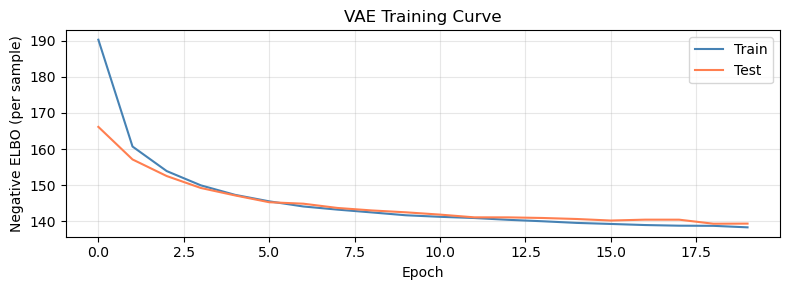

In [5]:
EPOCHS    = 20
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_losses = []
test_losses  = []

for epoch in range(1, EPOCHS + 1):
    # --- Training ---
    model.train()
    total_train = 0.0
    for x, _ in train_loader:
        x = x.to(DEVICE)
        optimizer.zero_grad()
        x_hat, mu, log_var = model(x)
        loss = elbo_loss(x, x_hat, mu, log_var)
        loss.backward()
        optimizer.step()
        total_train += loss.item()

    # --- Evaluation ---
    model.eval()
    total_test = 0.0
    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(DEVICE)
            x_hat, mu, log_var = model(x)
            total_test += elbo_loss(x, x_hat, mu, log_var).item()

    avg_train = total_train / len(train_set)
    avg_test  = total_test  / len(test_set)
    train_losses.append(avg_train)
    test_losses.append(avg_test)

    print(f'Epoch {epoch:2d}/{EPOCHS}  |  Train Loss: {avg_train:.2f}  |  Test Loss: {avg_test:.2f}')

plt.figure(figsize=(8, 3))
plt.plot(train_losses, label='Train', color='steelblue')
plt.plot(test_losses,  label='Test',  color='coral')
plt.xlabel('Epoch')
plt.ylabel('Negative ELBO (per sample)')
plt.title('VAE Training Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.4 Reconstruction — Can the VAE Reproduce What It Sees?

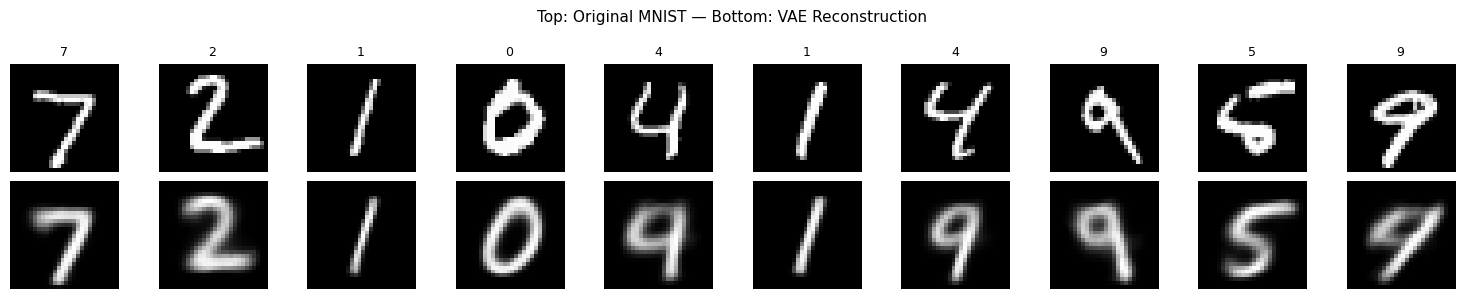

Note: reconstructions are slightly blurry — this is the characteristic VAE trade-off.


In [7]:
model.eval()
x_sample, labels = next(iter(test_loader))
x_sample = x_sample[:10].to(DEVICE)

with torch.no_grad():
    x_recon, _, _ = model(x_sample)

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    axes[0, i].imshow(x_sample[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f'{labels[i].item()}', fontsize=9)

    axes[1, i].imshow(x_recon[i].cpu().view(28, 28), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=9)
axes[1, 0].set_ylabel('Reconstructed', fontsize=9)
plt.suptitle('Top: Original MNIST — Bottom: VAE Reconstruction', fontsize=11)
plt.tight_layout()
plt.show()
print('Note: reconstructions are slightly blurry — this is the characteristic VAE trade-off.')

### 6.5 Generation — Create New Digits the VAE Has Never Seen!

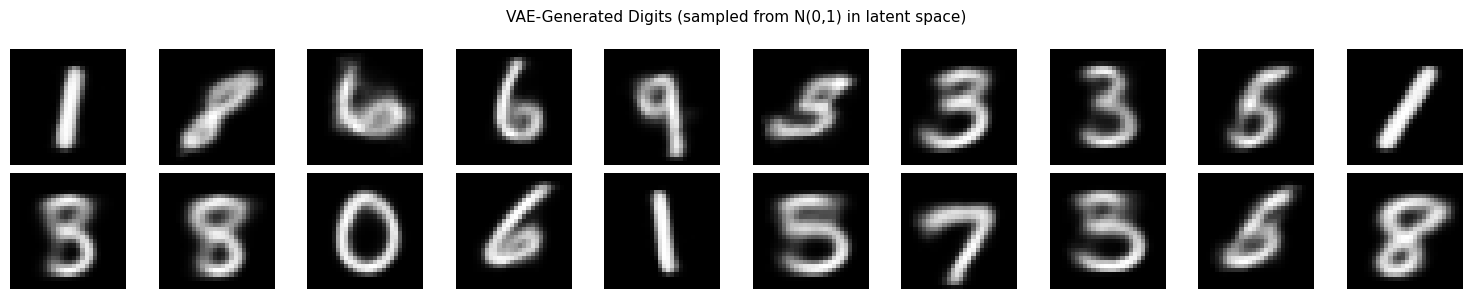

In [8]:
model.eval()
generated = model.generate(n_samples=20)

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].cpu().numpy(), cmap='gray')
    ax.axis('off')

plt.suptitle('VAE-Generated Digits (sampled from N(0,1) in latent space)', fontsize=11)
plt.tight_layout()
plt.show()

### 6.6 Visualise the 2D Latent Space

Because we chose `latent_dim=2`, we can plot the entire latent space on a scatter plot — one point per test image, coloured by digit class.

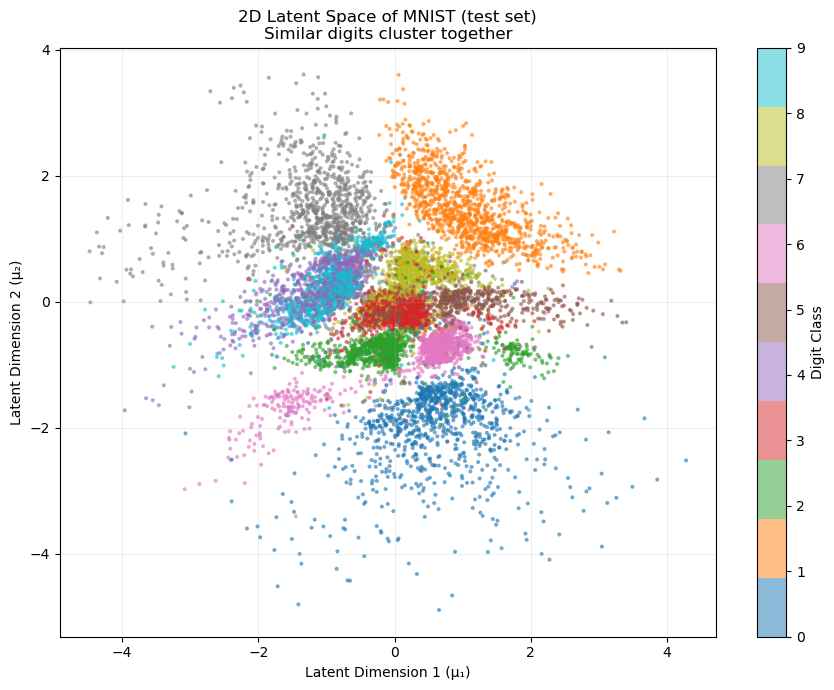

Observe how similar digits (e.g. 4 and 9) cluster near each other — the VAE has learned structure!


In [9]:
model.eval()
all_mu, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        mu, _ = model.encoder(x.to(DEVICE))
        all_mu.append(mu.cpu().numpy())
        all_labels.append(y.numpy())

all_mu     = np.concatenate(all_mu)
all_labels = np.concatenate(all_labels)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(all_mu[:, 0], all_mu[:, 1],
                      c=all_labels, cmap='tab10',
                      s=4, alpha=0.5)
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label('Digit Class')
plt.xlabel('Latent Dimension 1 (μ₁)')
plt.ylabel('Latent Dimension 2 (μ₂)')
plt.title('2D Latent Space of MNIST (test set)\nSimilar digits cluster together')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()
print('Observe how similar digits (e.g. 4 and 9) cluster near each other — the VAE has learned structure!')

### 6.7 Latent Space Manifold — Decode a Grid of Points

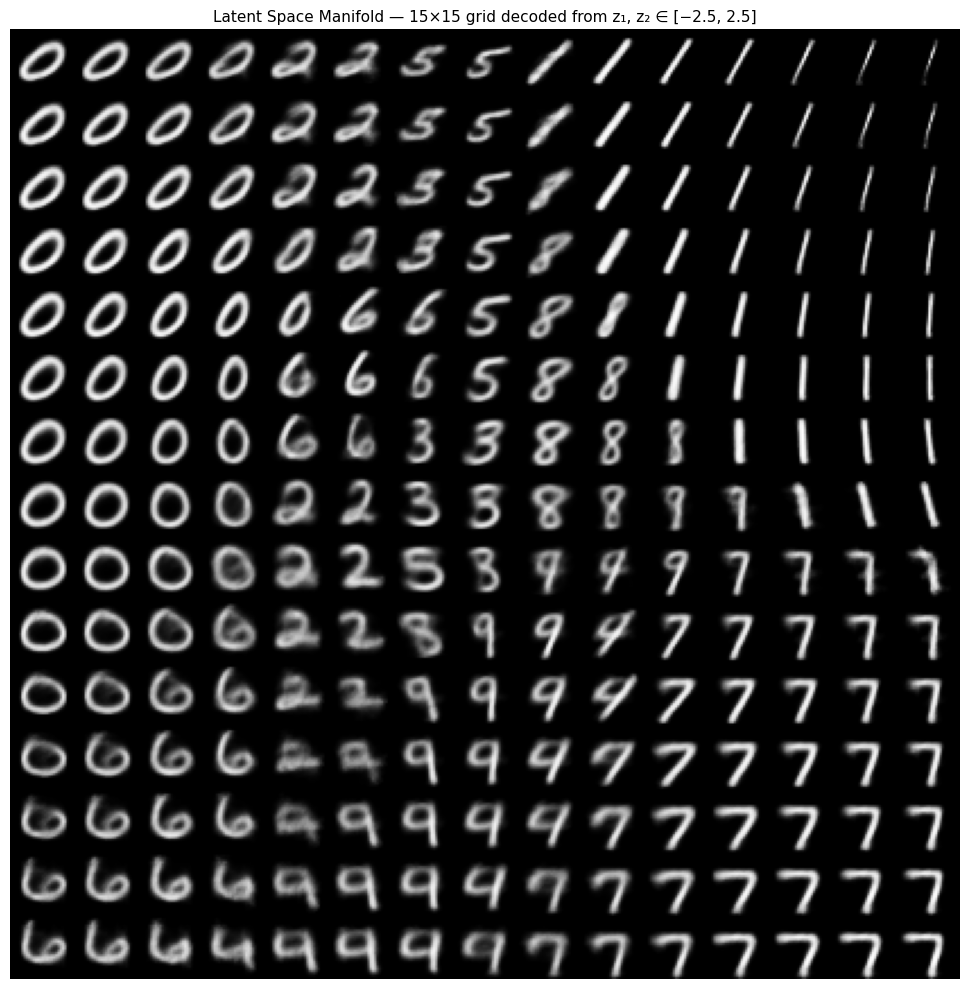

As you move smoothly across the latent space, digits morph gradually into one another.
This is the hallmark of a well-trained VAE: a smooth, continuous latent manifold.


In [10]:
n        = 15         # Grid size: n × n
grid_range = 2.5      # Explore ±2.5 standard deviations

# Create a grid of latent-space coordinates
z1 = np.linspace(-grid_range, grid_range, n)
z2 = np.linspace(-grid_range, grid_range, n)

canvas = np.zeros((28 * n, 28 * n))

model.eval()
with torch.no_grad():
    for i, z1_val in enumerate(z2[::-1]):  # y-axis from top to bottom
        for j, z2_val in enumerate(z1):
            z = torch.tensor([[z1_val, z2_val]], dtype=torch.float32).to(DEVICE)
            img = model.decoder(z).cpu().view(28, 28).numpy()
            canvas[i * 28:(i+1) * 28, j * 28:(j+1) * 28] = img

plt.figure(figsize=(10, 10))
plt.imshow(canvas, cmap='gray')
plt.title(f'Latent Space Manifold — {n}×{n} grid decoded from z₁, z₂ ∈ [−{grid_range}, {grid_range}]',
          fontsize=11)
plt.axis('off')
plt.tight_layout()
plt.show()
print('As you move smoothly across the latent space, digits morph gradually into one another.')
print('This is the hallmark of a well-trained VAE: a smooth, continuous latent manifold.')

### 6.8 Interpolation — Morphing One Digit Into Another

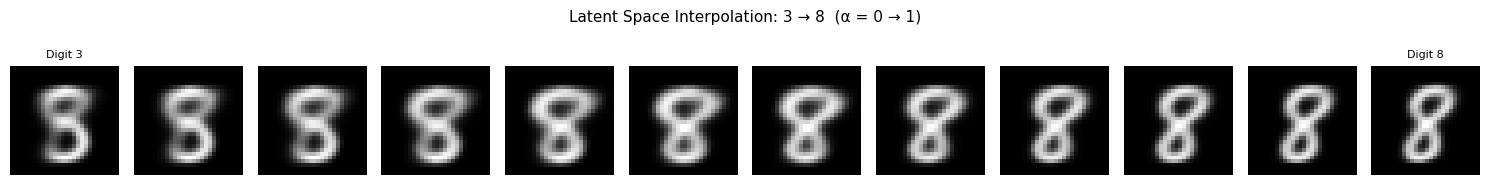

In [11]:
def get_latent(model, dataset, digit_class):
    """Return the latent mean of the first example of a given digit."""
    for x, y in DataLoader(dataset, batch_size=1, shuffle=True):
        if y.item() == digit_class:
            model.eval()
            with torch.no_grad():
                mu, _ = model.encoder(x.to(DEVICE))
            return mu

digit_A, digit_B = 3, 8
z_A = get_latent(model, test_set, digit_A)
z_B = get_latent(model, test_set, digit_B)

steps = 12
alphas = np.linspace(0, 1, steps)

fig, axes = plt.subplots(1, steps, figsize=(15, 2))
model.eval()
with torch.no_grad():
    for i, alpha in enumerate(alphas):
        z_interp = (1 - alpha) * z_A + alpha * z_B
        img = model.decoder(z_interp).cpu().view(28, 28).numpy()
        axes[i].imshow(img, cmap='gray')
        axes[i].axis('off')
        if i == 0:         axes[i].set_title(f'Digit {digit_A}', fontsize=8)
        if i == steps - 1: axes[i].set_title(f'Digit {digit_B}', fontsize=8)

plt.suptitle(f'Latent Space Interpolation: {digit_A} → {digit_B}  (α = 0 → 1)', fontsize=11)
plt.tight_layout()
plt.show()

## 7. Summary & Key Takeaways

### What You've Learned

| Concept | Key Point |
|---|---|
| **Autoencoder** | Compress → reconstruct; learns compact representations |
| **Variational** | Encode to distributions (μ, σ), not points → continuous latent space |
| **ANN Encoder** | Dense layers compress image (784D) → latent parameters (2D) |
| **ANN Decoder** | Dense layers expand latent code → reconstructed image (784D) |
| **ELBO loss** | BCE reconstruction + KL divergence; balances fidelity vs regularity |
| **Reparameterisation** | z = μ + σ·ε enables gradient-based training through sampling |
| **Generation** | Sample z ~ N(0,I), decode to get new synthetic images |
| **Interpolation** | Move smoothly in latent space → images morph continuously |

### Extensions to Explore
- **β-VAE** — increase the KL weight (β > 1) for disentangled representations
- **Conditional VAE (CVAE)** — condition on class label to generate specific digits
- **Convolutional VAE** — replace Dense layers with CNN layers for better image quality
- **VAE-GAN** — combine VAE latent structure with GAN sharpness
- **Hierarchical VAE** — stack multiple latent layers for richer representations

### Further Reading
- Kingma & Welling (2013) — *Auto-Encoding Variational Bayes* (original VAE paper)
- Doersch (2016) — *Tutorial on Variational Autoencoders*
- Higgins et al. (2017) — *β-VAE: Learning Basic Visual Concepts with a Constrained Variational Framework*

---
*Notebook prepared for general university use — Computer Science / Data Science / STEM.*